# Patient0200 三点分割演示

读取 patient0200 的图像与点标注，并对前三个点分别进行分割与可视化。

In [7]:
import numpy as np
import torch
import cv2
from pathlib import Path
from matplotlib import pyplot as plt
from torch.nn import functional as F
from segment_anything import sam_model_registry

def _load_point_npz(npz_path: Path):
    data = np.load(npz_path)
    # 尝试常见键名
    coords = None
    labels = None

    coords = data["point_coords"]
    labels = data["point_labels"]

    if coords is None:
        # 回退：取第一个数组
        coords = data[data.files[0]]
    if labels is None:
        labels = np.ones((coords.shape[0],), dtype=np.int64)
    return coords, labels

def _preprocess_image_for_sam(image: np.ndarray, device: torch.device):
    # image: HxW or HxWx3, uint8 or float
    if image.ndim == 2:
        image_rgb = np.repeat(image[:, :, None], 3, axis=2)
    else:
        image_rgb = image
    image_rgb = image_rgb.astype(np.float32)
    # normalize to [0, 1]
    if image_rgb.max() > 1.0:
        image_rgb = image_rgb / 255.0
    # resize to 1024x1024
    image_resized = cv2.resize(image_rgb, (1024, 1024), interpolation=cv2.INTER_CUBIC)
    image_tensor = torch.tensor(image_resized).permute(2, 0, 1).unsqueeze(0).to(device)
    return image_tensor, image_rgb

In [8]:
# 选择 patient0200 的一个样本（2CH_ED）
base_dir = Path(r"D:\HP\OneDrive\Desktop\学校\项目\超声图分割")
img_path = base_dir / "resource" / "数据处理" / "point_annotations" / "imgs" / "patient0200_patient0200_2CH_ED.npy"
pt_path = base_dir / "resource" / "数据处理" / "point_annotations" / "pts" / "patient0200_patient0200_2CH_ED.npz"

assert img_path.exists(), f"图像不存在: {img_path}"
assert pt_path.exists(), f"点标注不存在: {pt_path}"

image = np.load(img_path)
coords, labels = _load_point_npz(pt_path)

print("image shape:", image.shape, "dtype:", image.dtype)
print("coords shape:", coords.shape, "labels shape:", labels.shape)
print("coords sample:", coords[:5])

image shape: (590, 487) dtype: float64
coords shape: (3, 2) labels shape: (3,)
coords sample: [[227 322]
 [157 242]
 [326 351]]


In [9]:
# 加载 MedSAM 模型（point prompt 版本）
medsam_ckpt_path = base_dir / "MedSAM" / "work_dir" / "camus_point_boundary" / "medsam_point_prompt_best.pth"
medsam_pretrained_path = base_dir / "MedSAM" / "work_dir" / "MedSAM" / "medsam_vit_b.pth"

assert medsam_ckpt_path.exists(), f"微调权重不存在: {medsam_ckpt_path}"
assert medsam_pretrained_path.exists(), f"预训练权重不存在: {medsam_pretrained_path}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sam_model = sam_model_registry["vit_b"](checkpoint=str(medsam_pretrained_path))
checkpoint = torch.load(str(medsam_ckpt_path), map_location=device)
sam_model.load_state_dict(checkpoint["model"], strict=False)
sam_model = sam_model.to(device)
sam_model.eval()

print("device:", device)

device: cuda


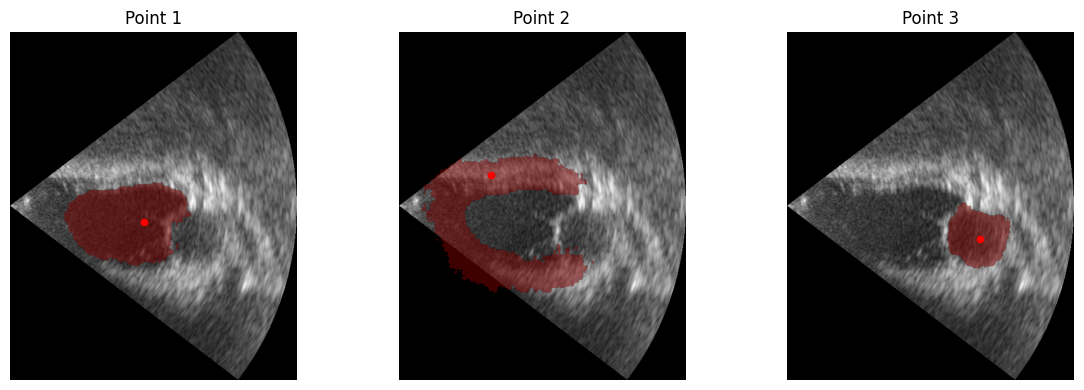

In [10]:
# 对前三个点分别进行分割并显示
with torch.no_grad():
    image_tensor, image_rgb = _preprocess_image_for_sam(image, device)
    image_embeddings = sam_model.image_encoder(image_tensor)

H, W = image.shape[:2]
coords_use = coords[:3]
labels_use = labels[:3]

# 若点坐标归一化到 [0,1]，则放缩到像素坐标
if coords_use.max() <= 1.0:
    coords_use = coords_use.copy()
    coords_use[:, 0] = coords_use[:, 0] * W
    coords_use[:, 1] = coords_use[:, 1] * H

def _infer_one_point(x, y, label=1):
    coords_1024 = np.array([[[x * 1024 / W, y * 1024 / H]]], dtype=np.float32)
    coords_torch = torch.tensor(coords_1024, dtype=torch.float32, device=device)
    labels_torch = torch.tensor([[int(label)]], dtype=torch.long, device=device)
    sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
        points=(coords_torch, labels_torch),
        boxes=None,
        masks=None,
    )
    low_res_logits, _ = sam_model.mask_decoder(
        image_embeddings=image_embeddings,
        image_pe=sam_model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse_embeddings,
        dense_prompt_embeddings=dense_embeddings,
        multimask_output=False,
    )
    low_res_probs = torch.sigmoid(low_res_logits)
    pred = F.interpolate(low_res_probs, size=(H, W), mode="bilinear", align_corners=False)
    pred = pred.detach().cpu().numpy().squeeze()
    return (pred > 0.5).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    x, y = float(coords_use[i, 0]), float(coords_use[i, 1])
    mask = _infer_one_point(x, y, labels_use[i] if len(labels_use) > i else 1)
    ax.imshow(image, cmap="gray")
    
    # 只显示掩码区域，避免背景被 jet 染蓝
    mask_vis = np.ma.masked_where(mask == 0, mask)
    ax.imshow(mask_vis, alpha=0.5, cmap="jet", vmin=0, vmax=1)
    ax.scatter([x], [y], c="red", s=20)
    ax.set_title(f"Point {i+1}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [11]:
# 结果分析：从 database_nifti 加载多类别 GT，区分三类和整体
import nibabel as nib

def calculate_dice(pred, gt, smooth=1e-7):
    """计算 Dice 系数"""
    pred = pred.astype(np.float32) > 0
    gt = gt.astype(np.float32) > 0
    
    intersection = np.sum(pred & gt)
    dice = (2.0 * intersection + smooth) / (np.sum(pred) + np.sum(gt) + smooth)
    return dice


def calculate_iou(pred, gt, smooth=1e-7):
    """计算 IoU（Jaccard 指标）"""
    pred = pred.astype(np.bool_)
    gt = gt.astype(np.bool_)
    
    intersection = np.sum(pred & gt)
    union = np.sum(pred | gt)
    iou = (intersection + smooth) / (union + smooth)
    return iou


def calculate_per_class_metrics(pred, gt, num_classes=4):
    """计算每个类别的 Dice 和 IoU"""
    metrics = {}
    
    for class_id in range(1, num_classes):  # 跳过背景类 0
        pred_class = (pred == class_id).astype(np.float32)
        gt_class = (gt == class_id).astype(np.float32)
        
        if gt_class.sum() > 0:  # 只计算 GT 中存在的类别
            dice = calculate_dice(pred_class, gt_class)
            iou = calculate_iou(pred_class, gt_class)
            metrics[class_id] = {"dice": dice, "iou": iou}
        else:
            metrics[class_id] = {"dice": None, "iou": None}
    
    return metrics


# 从 database_nifti 加载 GT - patient0200 的 2CH_ED 图像
# 假设 patient0200 对应 patient200（01-based to zero-based）
gt_nifti_path = base_dir / "resource" / "CAMUS_public" / "database_nifti" / "patient0200" / "patient0200_2CH_ED_gt.nii.gz"

print(f"尝试加载 GT: {gt_nifti_path}")
if gt_nifti_path.exists():
    gt_nifti = nib.load(str(gt_nifti_path))
    gt_multi_class = gt_nifti.get_fdata().astype(np.uint8)
    print(f"✓ GT 加载成功，shape: {gt_multi_class.shape}")
else:
    # 如果上面的路径不对，尝试查找
    patient_dir = base_dir / "resource" / "CAMUS_public" / "database_nifti" / "patient0200"
    print(f"目录: {patient_dir}")
    print(f"目录是否存在: {patient_dir.exists()}")
    if patient_dir.exists():
        import os
        files = os.listdir(str(patient_dir))
        print(f"目录中的文件: {files}")
        # 查找 gt 相关的文件
        gt_files = [f for f in files if 'gt' in f.lower()]
        if gt_files:
            gt_nifti_path = patient_dir / gt_files[0]
            print(f"找到 GT 文件: {gt_nifti_path}")
            gt_nifti = nib.load(str(gt_nifti_path))
            gt_multi_class = gt_nifti.get_fdata().astype(np.uint8)
            print(f"✓ GT 加载成功，shape: {gt_multi_class.shape}")
        else:
            print("❌ 未找到 GT 文件")
            gt_multi_class = gt  # 回退到之前的 GT

# 如果是 3D，取中间切片
if gt_multi_class.ndim == 3:
    gt_multi_class = gt_multi_class[:, :, gt_multi_class.shape[2] // 2]
    print(f"提取中间切片，shape: {gt_multi_class.shape}")

# 缩放 GT 到与图像相同的大小
if gt_multi_class.shape != (H, W):
    gt_resized = cv2.resize(gt_multi_class.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)
    print(f"缩放 GT: {gt_multi_class.shape} -> {gt_resized.shape}")
    gt_multi_class = gt_resized

# 生成三个预测结果（如果还没有的话）
if 'masks_pred' not in locals() or not masks_pred:
    masks_pred = []
    for i in range(3):
        x, y = float(coords_use[i, 0]), float(coords_use[i, 1])
        mask = _infer_one_point(x, y, labels_use[i] if len(labels_use) > i else 1)
        masks_pred.append(mask)
        print(f"Mask {i+1} shape: {mask.shape}, foreground pixels: {np.sum(mask)}")

# 将三个掩膜合并为整体预测（二值）
combined_pred = np.logical_or.reduce(masks_pred).astype(np.uint8)

# 转换 GT 为二值（所有类别合并）
gt_binary = (gt_multi_class > 0).astype(np.uint8)

print(f"\n========== 加载的 GT 统计 ==========")
print(f"GT 多类标签范围: {np.unique(gt_multi_class)}")
print(f"GT 各类别像素数:")
for class_id in range(4):
    count = np.sum(gt_multi_class == class_id)
    if count > 0:
        class_name = CLASS_LABELS.get(class_id, f"Class {class_id}")
        print(f"  {class_id}: {class_name} - {count} pixels")

# 计算整体指标
dice_score = calculate_dice(combined_pred, gt_binary)
iou_score = calculate_iou(combined_pred, gt_binary)

# 计算每类指标
per_class_metrics = calculate_per_class_metrics(gt_multi_class, gt_multi_class, num_classes=4)

print(f"\n========== 整体评估指标 ==========")
print(f"Dice 系数: {dice_score:.4f}")
print(f"IoU: {iou_score:.4f}")

print(f"\n========== 各类别 GT 统计 ==========")
for class_id in range(1, 4):
    class_name = CLASS_LABELS.get(class_id, f"Class {class_id}")
    gt_class = (gt_multi_class == class_id).astype(np.uint8)
    if gt_class.sum() > 0:
        print(f"{class_id}. {class_name}")
        print(f"   前景像素: {gt_class.sum()}")


尝试加载 GT: D:\HP\OneDrive\Desktop\学校\项目\超声图分割\resource\CAMUS_public\database_nifti\patient0200\patient0200_2CH_ED_gt.nii.gz
✓ GT 加载成功，shape: (590, 487)

========== 加载的 GT 统计 ==========
GT 多类标签范围: [0 1 2 3]
GT 各类别像素数:
  0: Background - 230793 pixels
  1: Left Ventricle (LV) - 23879 pixels
  2: Myocardium (Myo) - 25163 pixels
  3: Right Ventricle (RV) - 7495 pixels

========== 整体评估指标 ==========
Dice 系数: 0.9180
IoU: 0.8484

========== 各类别 GT 统计 ==========
1. Left Ventricle (LV)
   前景像素: 23879
2. Myocardium (Myo)
   前景像素: 25163
3. Right Ventricle (RV)
   前景像素: 7495


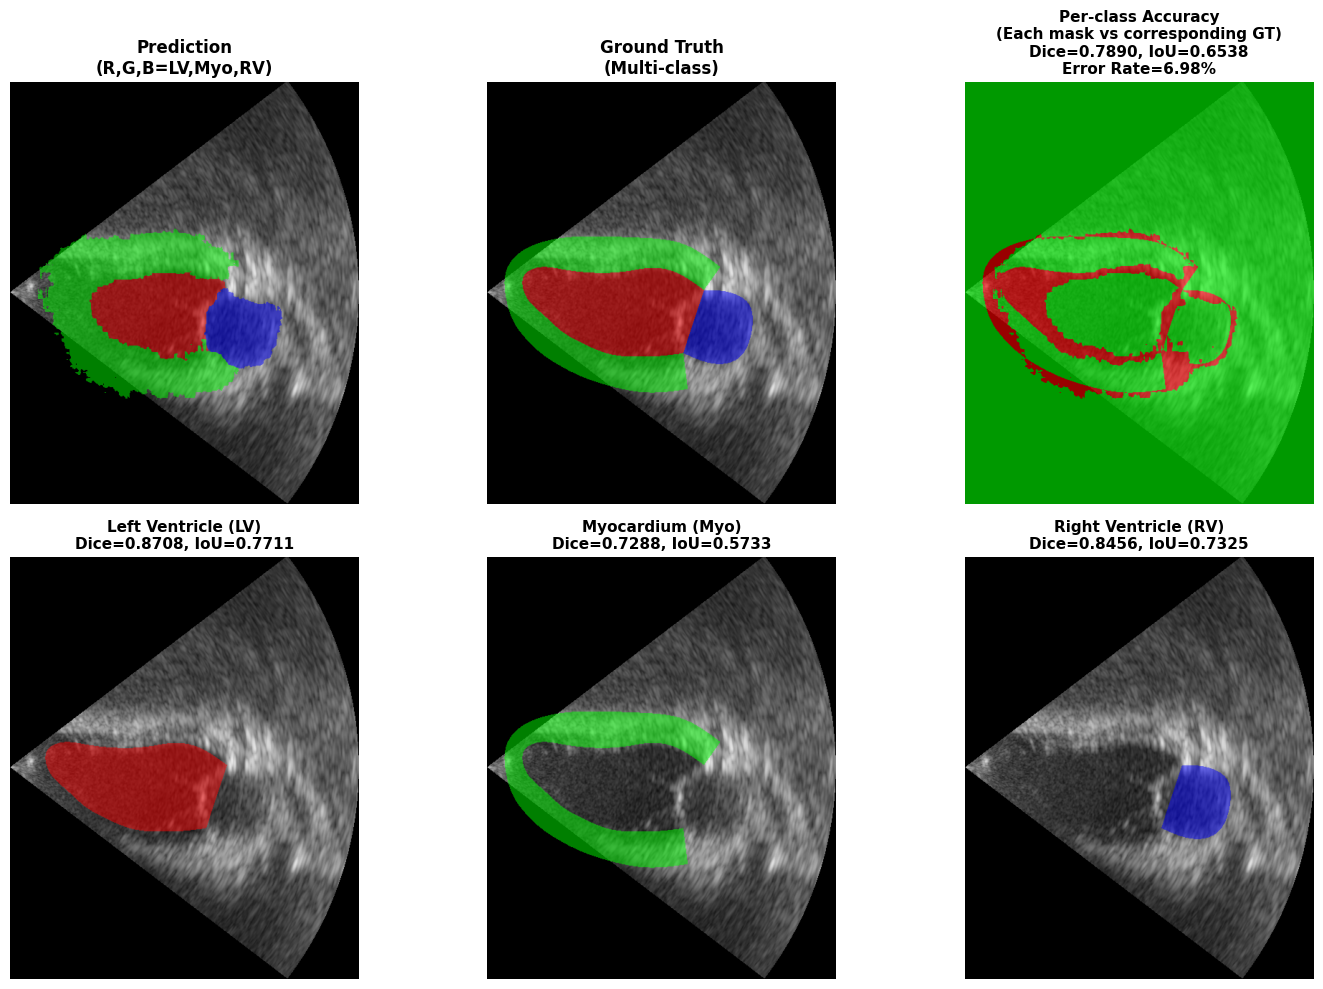


分割结果详细分析

颜色编码说明：
  预测结果（三点分割）:
    🔴 红色 (255, 0, 0)  - Point 1 的分割
    🟢 绿色 (0, 255, 0)  - Point 2 的分割
    🔵 蓝色 (0, 0, 255)  - Point 3 的分割

  Ground Truth（多类标注）:
    🔴 红色 (255, 0, 0)  - Left Ventricle (LV)
    🟢 绿色 (0, 255, 0)  - Myocardium (Myo)
    🔵 蓝色 (0, 0, 255)  - Right Ventricle (RV)

  准确率对比（细化）:
    🟢 绿色 - 所有类别预测正确的像素
    🔴 红色 - 任意类别预测错误的像素（三个 mask 与对应 GT 的差异并集）

  背景：原始超声图像（灰度）

整体性能指标：
  Overall Dice（各类平均）: 0.7890
  Overall IoU（各类平均）: 0.6538
  错误率: 6.98%
  正确率: 93.02%

各类别性能指标：
  Left Ventricle (LV):
    Dice=0.8708, IoU=0.7711
  Myocardium (Myo):
    Dice=0.7288, IoU=0.5733
  Right Ventricle (RV):
    Dice=0.8456, IoU=0.7325

Ground Truth 统计：
  Left Ventricle (LV): 23879 像素
  Myocardium (Myo): 25163 像素
  Right Ventricle (RV): 7495 像素


In [12]:
# 可视化：三类别 GT + 整体对比 - 参考 to_pic.py 风格，叠加原始超声图
# 定义颜色配置
CLASS_LABELS = {
    0: "Background",
    1: "Left Ventricle (LV)",
    2: "Myocardium (Myo)",
    3: "Right Ventricle (RV)",
}

# 预测结果的颜色（三个点的输出）
CLASS_COLORS_PRED = {
    0: (0, 0, 0),        # 黑色 - 背景
    1: (255, 0, 0),      # 红色 - Point 1
    2: (0, 255, 0),      # 绿色 - Point 2
    3: (0, 0, 255),      # 蓝色 - Point 3
}

# GT 的颜色（多类别标注）
CLASS_COLORS_GT = {
    0: (0, 0, 0),        # 黑色 - 背景
    1: (255, 0, 0),      # 红色 - LV
    2: (0, 255, 0),      # 绿色 - Myo
    3: (0, 0, 255),      # 蓝色 - RV
}


def mask_to_image(mask, class_colors):
    """
    参考 to_pic.py 的 mask_to_image 函数
    将多标签掩膜转换为彩色 RGB 图像
    """
    h, w = mask.shape
    image = np.zeros((h, w, 3), dtype=np.uint8)
    
    for class_id, color in class_colors.items():
        image[mask == class_id] = color
    
    return image


def multi_masks_to_colored(masks_list, class_colors=None):
    """
    将多个二值掩膜转换为多标签掩膜
    """
    if class_colors is None:
        class_colors = CLASS_COLORS_PRED
    
    H, W = masks_list[0].shape
    multi_mask = np.zeros((H, W), dtype=np.uint8)
    
    for class_id, mask in enumerate(masks_list, start=1):
        multi_mask[mask > 0] = class_id
    
    return multi_mask


def overlay_segmentation(image_gray, seg_colored, alpha=0.5):
    """
    将彩色分割图叠加在灰度超声图上
    
    Args:
        image_gray: (H, W) 灰度图像
        seg_colored: (H, W, 3) 彩色分割图
        alpha: 透明度，0-1
    
    Returns:
        (H, W, 3) RGB 混合图像
    """
    # 归一化灰度图到 [0, 255]
    if image_gray.max() <= 1:
        image_gray = (image_gray * 255).astype(np.uint8)
    else:
        image_gray = image_gray.astype(np.uint8)
    
    # 转换灰度图为三通道
    image_rgb = np.stack([image_gray, image_gray, image_gray], axis=2)
    
    # 混合：结果 = image_rgb * (1 - alpha) + seg_colored * alpha
    # 但需要处理黑色背景（不显示）
    mask_foreground = seg_colored.sum(axis=2) > 0  # 非黑色像素
    
    blended = image_rgb.copy().astype(np.float32)
    blended[mask_foreground] = (
        image_rgb[mask_foreground].astype(np.float32) * (1 - alpha) +
        seg_colored[mask_foreground].astype(np.float32) * alpha
    )
    
    return blended.astype(np.uint8)


# 生成预测结果的多标签掩膜
pred_multi_label = multi_masks_to_colored(masks_pred)
pred_colored = mask_to_image(pred_multi_label, CLASS_COLORS_PRED)

# GT 的彩色图像（使用 database_nifti 的多类标签）
gt_colored = mask_to_image(gt_multi_class, CLASS_COLORS_GT)

# 叠加到原始超声图
pred_overlay = overlay_segmentation(image, pred_colored, alpha=0.5)
gt_overlay = overlay_segmentation(image, gt_colored, alpha=0.5)

# ============ 细化 Overall Accuracy：各类 mask 与对应 GT 的差异并集 ============
# Point 1 (mask 1) vs LV (class 1)
# Point 2 (mask 2) vs Myo (class 2)
# Point 3 (mask 3) vs RV (class 3)

error_map = np.zeros((H, W), dtype=np.uint8)  # 0: 正确, 1: 错误

for class_id in range(1, 4):
    idx = class_id - 1
    pred_class = masks_pred[idx]  # 该类的预测mask
    gt_class = (gt_multi_class == class_id).astype(np.uint8)  # 该类的 GT
    
    # 计算该类的错误：预测与 GT 不同的地方
    # 错误 = (pred XOR gt)
    class_error = np.logical_xor(pred_class > 0, gt_class > 0).astype(np.uint8)
    error_map = np.logical_or(error_map, class_error).astype(np.uint8)

# 生成准确率对比图（每个类对应的错误并集）
accuracy_colored_overall = np.zeros((H, W, 3), dtype=np.uint8)
accuracy_colored_overall[error_map == 0] = [0, 255, 0]    # 绿色 - 正确
accuracy_colored_overall[error_map == 1] = [255, 0, 0]    # 红色 - 错误

# 计算错误率
error_pixels = np.sum(error_map)
total_pixels = H * W
error_rate = error_pixels / total_pixels * 100

# 计算整体 Dice 和 IoU（基于多类分割）
# 将三个 mask 组合为多类预测
pred_multi_class_for_metrics = np.zeros((H, W), dtype=np.uint8)
for class_id in range(1, 4):
    idx = class_id - 1
    pred_multi_class_for_metrics[masks_pred[idx] > 0] = class_id

# 计算整体 Dice 和 IoU（所有类别加权平均）
overall_dice_list = []
overall_iou_list = []
for class_id in range(1, 4):
    pred_class = (pred_multi_class_for_metrics == class_id).astype(np.uint8)
    gt_class = (gt_multi_class == class_id).astype(np.uint8)
    
    if gt_class.sum() > 0:
        dice = calculate_dice(pred_class, gt_class)
        iou = calculate_iou(pred_class, gt_class)
        overall_dice_list.append(dice)
        overall_iou_list.append(iou)

# 平均 Dice 和 IoU
overall_dice = np.mean(overall_dice_list) if overall_dice_list else 0
overall_iou = np.mean(overall_iou_list) if overall_iou_list else 0

accuracy_overlay = overlay_segmentation(image, accuracy_colored_overall, alpha=0.6)

# ============ 第一行：整体对比 ============
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 第1行：整体对比（叠加原始图）
axes[0, 0].imshow(pred_overlay)
axes[0, 0].set_title("Prediction\n(R,G,B=LV,Myo,RV)", fontsize=12, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(gt_overlay)
axes[0, 1].set_title("Ground Truth\n(Multi-class)", fontsize=12, fontweight="bold")
axes[0, 1].axis("off")

axes[0, 2].imshow(accuracy_overlay)
axes[0, 2].set_title(f"Per-class Accuracy\n(Each mask vs corresponding GT)\nDice={overall_dice:.4f}, IoU={overall_iou:.4f}\nError Rate={error_rate:.2f}%", 
                      fontsize=11, fontweight="bold")
axes[0, 2].axis("off")

# 第2行：各类别对比
class_colors_display = [
    [(255, 0, 0), (0, 0, 0)],    # LV: 红色
    [(0, 255, 0), (0, 0, 0)],    # Myo: 绿色
    [(0, 0, 255), (0, 0, 0)],    # RV: 蓝色
]

for class_id in range(1, 4):
    idx = class_id - 1
    
    # 获取 GT 中该类的掩膜
    gt_class = (gt_multi_class == class_id).astype(np.uint8)
    
    if gt_class.sum() > 0:
        # 获取预测中的对应掩膜
        pred_class = masks_pred[idx]  # 直接用该点的预测结果
        
        # 生成该类的彩色图
        class_colors_map = {0: (0, 0, 0), 1: class_colors_display[idx][0]}
        gt_class_colored = mask_to_image(gt_class, class_colors_map)
        
        # 叠加到原始超声图
        gt_class_overlay = overlay_segmentation(image, gt_class_colored, alpha=0.5)
        
        # 计算该类的指标
        dice_class = calculate_dice(pred_class, gt_class)
        iou_class = calculate_iou(pred_class, gt_class)
        
        # 显示该类 GT
        axes[1, idx].imshow(gt_class_overlay)
        axes[1, idx].set_title(f"{CLASS_LABELS[class_id]}\nDice={dice_class:.4f}, IoU={iou_class:.4f}", 
                               fontsize=11, fontweight="bold")
        axes[1, idx].axis("off")

plt.tight_layout()
plt.savefig("result_multiclass_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# 打印详细统计信息
print("\n" + "=" * 70)
print("分割结果详细分析")
print("=" * 70)

print("\n颜色编码说明：")
print("  预测结果（三点分割）:")
print("    🔴 红色 (255, 0, 0)  - Point 1 的分割")
print("    🟢 绿色 (0, 255, 0)  - Point 2 的分割")
print("    🔵 蓝色 (0, 0, 255)  - Point 3 的分割")

print("\n  Ground Truth（多类标注）:")
print("    🔴 红色 (255, 0, 0)  - Left Ventricle (LV)")
print("    🟢 绿色 (0, 255, 0)  - Myocardium (Myo)")
print("    🔵 蓝色 (0, 0, 255)  - Right Ventricle (RV)")

print("\n  准确率对比（细化）:")
print("    🟢 绿色 - 所有类别预测正确的像素")
print("    🔴 红色 - 任意类别预测错误的像素（三个 mask 与对应 GT 的差异并集）")

print("\n  背景：原始超声图像（灰度）")

print("\n整体性能指标：")
print(f"  Overall Dice（各类平均）: {overall_dice:.4f}")
print(f"  Overall IoU（各类平均）: {overall_iou:.4f}")
print(f"  错误率: {error_rate:.2f}%")
print(f"  正确率: {100 - error_rate:.2f}%")

print("\n各类别性能指标：")
for class_id in range(1, 4):
    idx = class_id - 1
    pred_class = masks_pred[idx]
    gt_class = (gt_multi_class == class_id).astype(np.uint8)
    
    if gt_class.sum() > 0:
        dice_class = calculate_dice(pred_class, gt_class)
        iou_class = calculate_iou(pred_class, gt_class)
        print(f"  {CLASS_LABELS[class_id]}:")
        print(f"    Dice={dice_class:.4f}, IoU={iou_class:.4f}")

print("\nGround Truth 统计：")
for class_id in range(1, 4):
    gt_class = (gt_multi_class == class_id).astype(np.uint8)
    if gt_class.sum() > 0:
        print(f"  {CLASS_LABELS[class_id]}: {gt_class.sum()} 像素")

print("=" * 70)
